<a href="https://colab.research.google.com/github/dhanwariagarvit21/cont-s-stylized-facts/blob/main/Aggregational_Gaussianity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import scipy.stats as stats
import statsmodels.api as sm
import os

In [28]:

path = kagglehub.dataset_download("debashis74017/nifty-50-minute-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nifty-50-minute-data' dataset.
Path to dataset files: /kaggle/input/nifty-50-minute-data


In [29]:

file_name = 'NIFTY 50_minute.csv'
full_file_path = os.path.join(path, file_name)
data_f = pd.read_csv(full_file_path)

In [30]:
data_f

,date,open,high,low,close,volume
0,2015-01-09 09:15:00,8285.45,8295.90,8285.45,8292.10,0
1,2015-01-09 09:16:00,8292.60,8293.60,8287.20,8288.15,0
2,2015-01-09 09:17:00,8287.40,8293.90,8287.40,8293.90,0
3,2015-01-09 09:18:00,8294.25,8300.65,8293.90,8300.65,0
4,2015-01-09 09:19:00,8300.60,8301.30,8298.75,8301.20,0
...,...,...,...,...,...,...
1048733,2026-05-15 13:16:00,23774.90,23778.65,23772.15,23773.70,0
1048734,2026-05-15 13:17:00,23773.55,23775.85,23771.60,23772.85,0
1048735,2026-05-15 13:18:00,23772.40,23776.30,23770.45,23773.00,0
1048736,2026-05-15 13:19:00,23773.35,23785.85,23773.35,23785.85,0


In [31]:
data_f['date'] = pd.to_datetime(data_f['date'])
data_f = data_f.sort_values('date').reset_index(drop=True)
data_f = data_f.set_index('date')
data_f['log_return'] = np.log(data_f['close'] / data_f['close'].shift(1))

In [32]:
def aggregate_returns(df, minutes):
    temp = df[['close']].copy()
    temp['log_return'] = np.log(
        temp['close'] / temp['close'].shift(1)
    )
    temp['trading_day'] = temp.index.date
    def aggregate_day(group):
        returns = group['log_return'].dropna().values
        n_blocks = len(returns) // minutes
        if n_blocks == 0:
            return pd.Series(dtype=float)

        returns = returns[:n_blocks * minutes]
        returns = returns.reshape(n_blocks, minutes)
        aggregated = returns.sum(axis=1)
        return pd.Series(aggregated)

    result = temp.groupby('trading_day', group_keys=False).apply(
        aggregate_day
    )
    result = result.reset_index(drop=True)
    return result

In [33]:
returns_50 = aggregate_returns(data_f, 50)
returns_100 = aggregate_returns(data_f, 100)
returns_150 = aggregate_returns(data_f, 150)
returns_200 = aggregate_returns(data_f, 200)
returns_250 = aggregate_returns(data_f, 250)
returns_300 = aggregate_returns(data_f, 300)

/tmp/ipykernel_808/1606493887.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = temp.groupby('trading_day', group_keys=False).apply(
/tmp/ipykernel_808/1606493887.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = temp.groupby('trading_day', group_keys=False).apply(
/tmp/ipykernel_808/1606493887.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This b

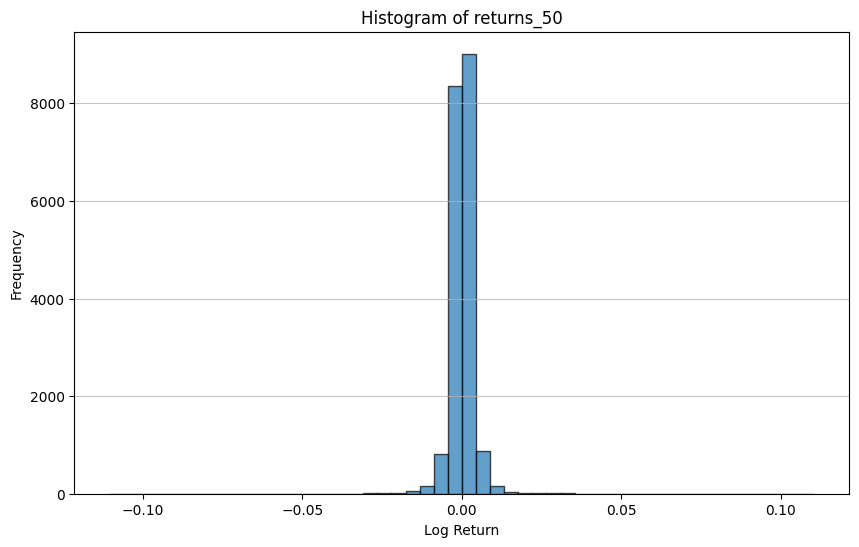

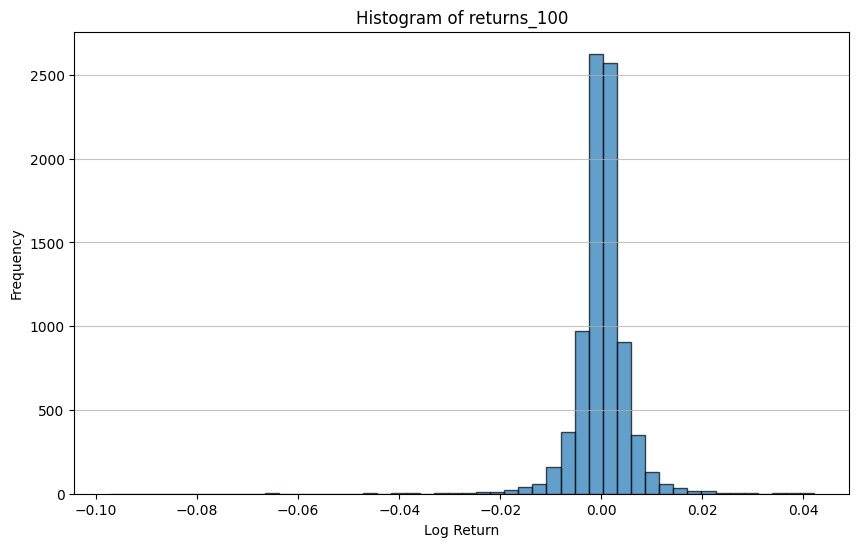

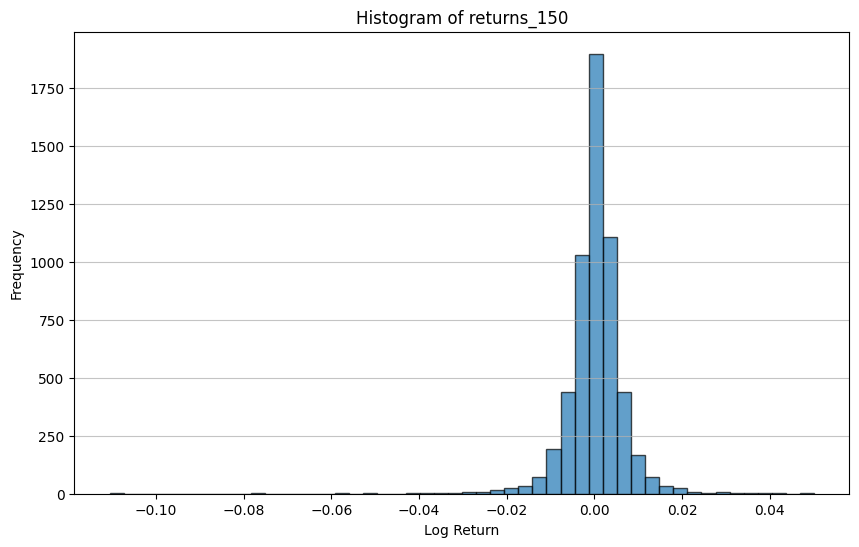

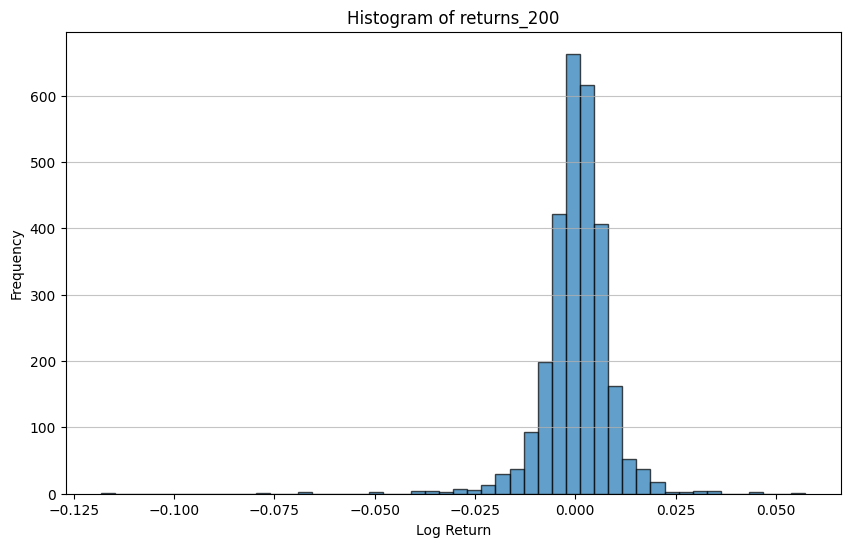

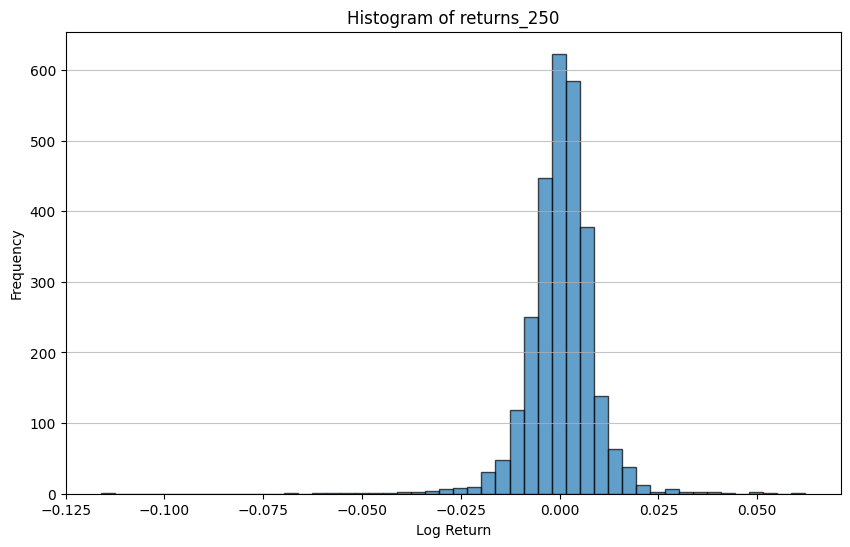

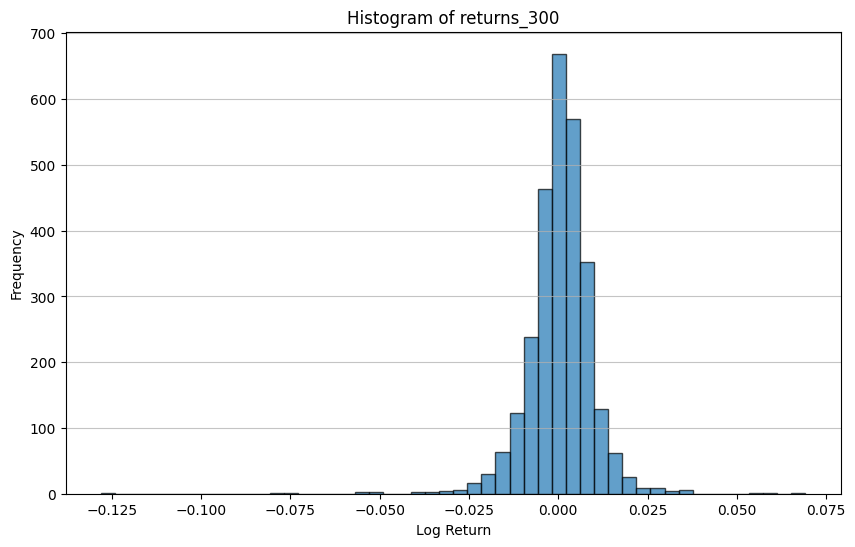

In [34]:
returns_series = {
    'returns_50': returns_50,
    'returns_100': returns_100,
    'returns_150': returns_150,
    'returns_200': returns_200,
    'returns_250': returns_250,
    'returns_300': returns_300
}
for name, series in returns_series.items():
    plt.figure(figsize=(10, 6))
    plt.hist(series.dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.title(f'Histogram of {name}')
    plt.xlabel('Log Return')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

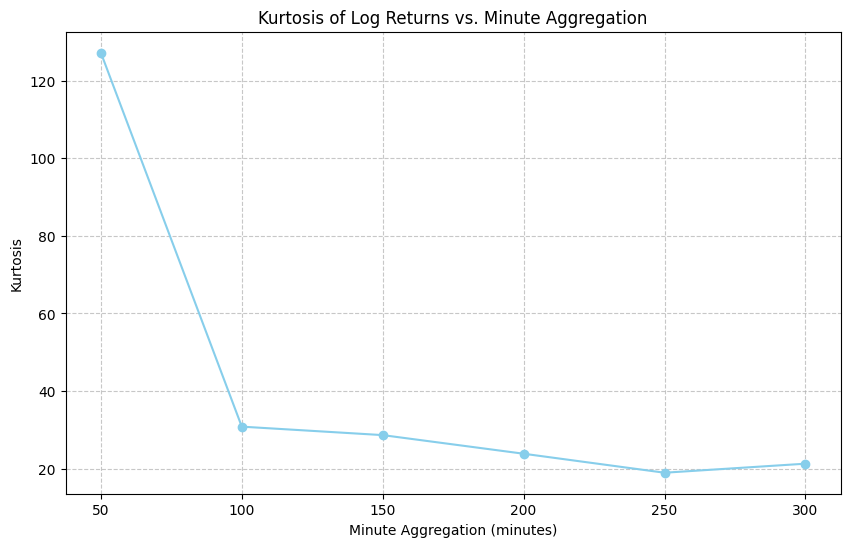

In [35]:
kurtosis_values = {}
minute_aggregations = []
for name, series in returns_series.items():
    minutes = int(name.split('_')[1])
    kurt = stats.kurtosis(series.dropna())
    kurtosis_values[minutes] = kurt
    minute_aggregations.append(minutes)
sorted_minutes = sorted(kurtosis_values.keys())
sorted_kurtosis = [kurtosis_values[m] for m in sorted_minutes]
plt.figure(figsize=(10, 6))
plt.plot(sorted_minutes, sorted_kurtosis, marker='o', linestyle='-', color='skyblue')
plt.title('Kurtosis of Log Returns vs. Minute Aggregation')
plt.xlabel('Minute Aggregation (minutes)')
plt.ylabel('Kurtosis')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(sorted_minutes)
plt.show()

In [36]:
def jarque_bera(returns):
    n = len(returns)
    S = stats.skew(returns, bias=False)
    K = stats.kurtosis(returns, fisher=False, bias=False)
    JB = (n / 6) * (S**2 + ((K - 3) ** 2) / 4)
    p_value = 1 - stats.chi2.cdf(JB, df=2)
    return JB, p_value

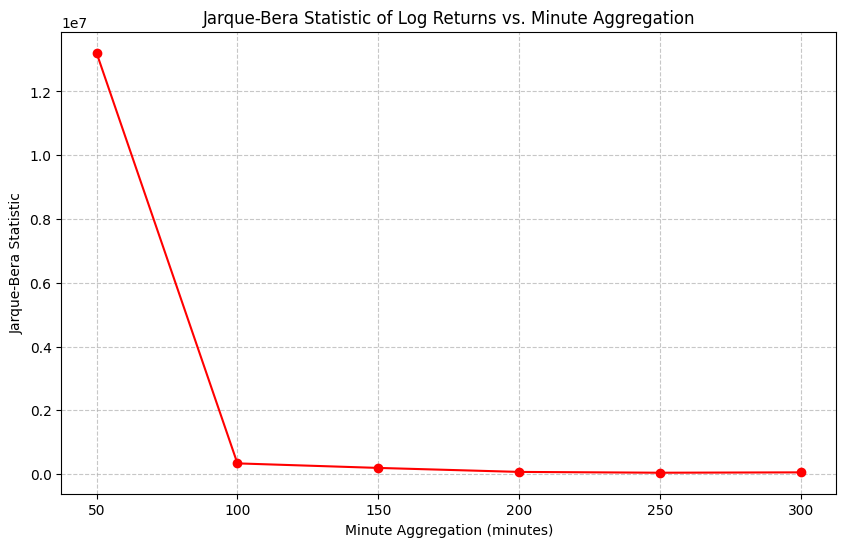

In [38]:
jarque_bera_values = {}
for name, series in returns_series.items():
    minutes = int(name.split('_')[1])
    jb_stat, p_value = jarque_bera(series.dropna())
    jarque_bera_values[minutes] = jb_stat
sorted_minutes_jb = sorted(jarque_bera_values.keys())
sorted_jb = [jarque_bera_values[m] for m in sorted_minutes_jb]
plt.figure(figsize=(10, 6))
plt.plot(sorted_minutes_jb, sorted_jb, marker='o', linestyle='-', color='red')
plt.title('Jarque-Bera Statistic of Log Returns vs. Minute Aggregation')
plt.xlabel('Minute Aggregation (minutes)')
plt.ylabel('Jarque-Bera Statistic')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(sorted_minutes_jb)
plt.show()